In [82]:
import pandas as pd
from pathlib import Path

csv_files = [
    "../data/QCEW_2018_q1-q4_Butte_County.csv",
    "../data/QCEW_2018_q1-q4_Shasta_County.csv",
    "../data/QCEW_2019_q1-q4_Butte_County.csv",
    "../data/QCEW_2019_q1-q4_Shasta_County.csv",
]

dfs = [pd.read_csv(file) for file in csv_files]

combined_df = pd.concat(dfs, ignore_index=True)

combined_df.to_csv("../data/combined.csv", index=False)

print("../data/Combined CSV saved as combined.csv")
print(combined_df.shape)

../data/Combined CSV saved as combined.csv
(25548, 47)


        date                area_title  employment_level  monthly_change
0 2018-01-01  Butte County, California             80491             NaN
1 2018-02-01  Butte County, California             82248          1757.0
2 2018-03-01  Butte County, California             83189           941.0
3 2018-04-01  Butte County, California             84454          1265.0
4 2018-05-01  Butte County, California             85270           816.0


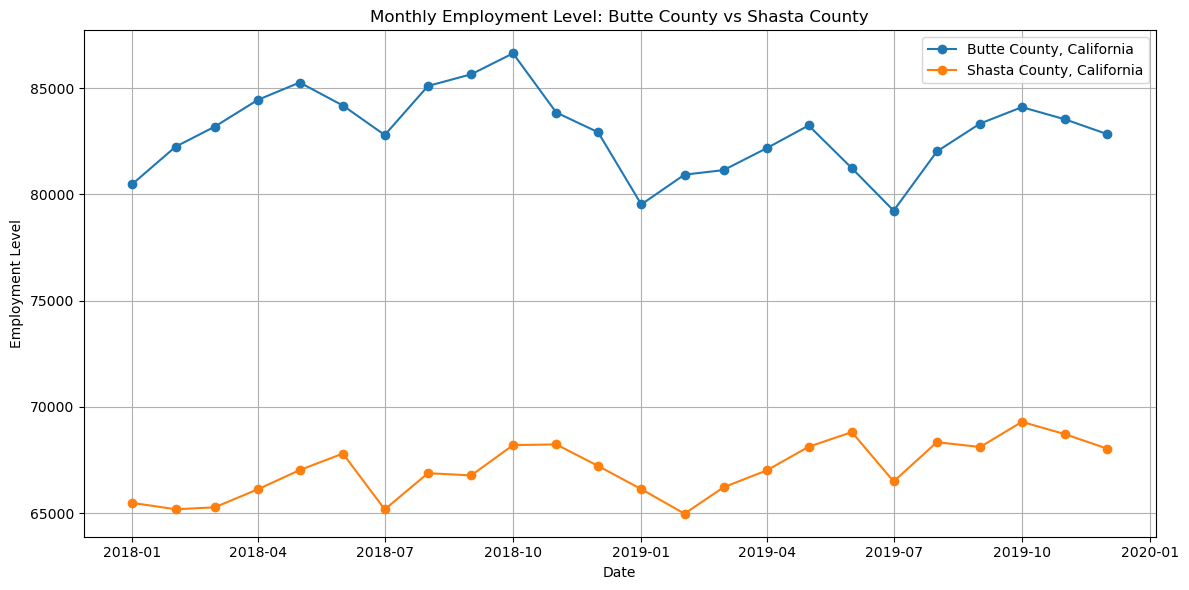

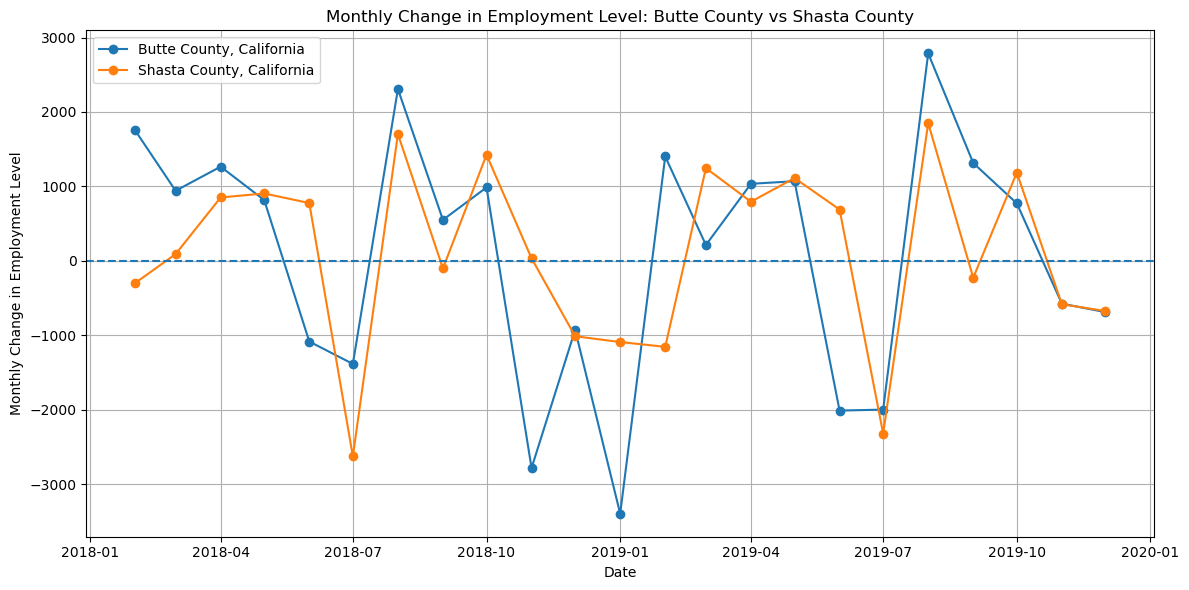

In [83]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/combined.csv")

target_areas = ["Butte County, California", "Shasta County, California"]

target_industry = "10 Total, all industries"

df_filtered = df[
    (df["area_title"].isin(target_areas)) & (df["industry_title"] == target_industry)
].copy()

df_filtered = df_filtered[df_filtered["own_title"] == "Total Covered"]

monthly_rows = []

for _, row in df_filtered.iterrows():
    year = int(row["year"])
    qtr = int(row["qtr"])

    start_month = (qtr - 1) * 3 + 1

    monthly_rows.append(
        {
            "date": pd.Timestamp(year=year, month=start_month, day=1),
            "area_title": row["area_title"],
            "employment_level": row["month1_emplvl"],
        }
    )

    monthly_rows.append(
        {
            "date": pd.Timestamp(year=year, month=start_month + 1, day=1),
            "area_title": row["area_title"],
            "employment_level": row["month2_emplvl"],
        }
    )

    monthly_rows.append(
        {
            "date": pd.Timestamp(year=year, month=start_month + 2, day=1),
            "area_title": row["area_title"],
            "employment_level": row["month3_emplvl"],
        }
    )

monthly_df = pd.DataFrame(monthly_rows)

monthly_df = monthly_df.sort_values(["area_title", "date"])

monthly_df["monthly_change"] = monthly_df.groupby("area_title")[
    "employment_level"
].diff()

print(monthly_df.head())

plt.figure(figsize=(12, 6))

for area in target_areas:
    area_data = monthly_df[monthly_df["area_title"] == area]
    plt.plot(area_data["date"], area_data["employment_level"], marker="o", label=area)

plt.title("Monthly Employment Level: Butte County vs Shasta County")
plt.xlabel("Date")
plt.ylabel("Employment Level")
plt.legend()
plt.grid(True)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../results/employment_level_butte_shasta.png")
plt.show()


plt.figure(figsize=(12, 6))

for area in target_areas:
    area_data = monthly_df[monthly_df["area_title"] == area]
    plt.plot(area_data["date"], area_data["monthly_change"], marker="o", label=area)

plt.axhline(0, linestyle="--")
plt.title("Monthly Change in Employment Level: Butte County vs Shasta County")
plt.xlabel("Date")
plt.ylabel("Monthly Change in Employment Level")
plt.legend()
plt.grid(True)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../results/employment_monthly_change_butte_shasta.png")
plt.show()

In [84]:
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

df = pd.read_csv("../data/combined.csv")

df.columns = df.columns.str.strip()

target_areas = ["Butte County, California", "Shasta County, California"]

target_industry = "10 Total, all industries"


df_filtered = df[
    (df["area_title"].isin(target_areas)) & (df["industry_title"] == target_industry)
].copy()

df_filtered = df_filtered[df_filtered["own_title"] == "Total Covered"]


monthly_rows = []

for _, row in df_filtered.iterrows():
    year = int(row["year"])
    qtr = int(row["qtr"])

    start_month = (qtr - 1) * 3 + 1

    monthly_rows.extend(
        [
            {
                "date": pd.Timestamp(year=year, month=start_month, day=1),
                "area_title": row["area_title"],
                "employment_level": row["month1_emplvl"],
            },
            {
                "date": pd.Timestamp(year=year, month=start_month + 1, day=1),
                "area_title": row["area_title"],
                "employment_level": row["month2_emplvl"],
            },
            {
                "date": pd.Timestamp(year=year, month=start_month + 2, day=1),
                "area_title": row["area_title"],
                "employment_level": row["month3_emplvl"],
            },
        ]
    )

monthly_df = pd.DataFrame(monthly_rows)


# Create DID variables
monthly_df["treated"] = (monthly_df["area_title"] == "Butte County, California").astype(
    int
)

# Camp Fire started Nov 8, 2018
monthly_df["post"] = (monthly_df["date"] >= pd.Timestamp("2018-11-01")).astype(int)

# DID interaction
monthly_df["did"] = monthly_df["treated"] * monthly_df["post"]

print(monthly_df.head())


        date                area_title  employment_level  treated  post  did
0 2018-01-01  Butte County, California             80491        1     0    0
1 2018-02-01  Butte County, California             82248        1     0    0
2 2018-03-01  Butte County, California             83189        1     0    0
3 2018-04-01  Butte County, California             84454        1     0    0
4 2018-05-01  Butte County, California             85270        1     0    0


In [85]:
model = smf.ols("employment_level ~ treated + post + did", data=monthly_df).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       employment_level   R-squared:                       0.971
Model:                            OLS   Adj. R-squared:                  0.969
Method:                 Least Squares   F-statistic:                     483.1
Date:                Tue, 05 May 2026   Prob (F-statistic):           1.12e-33
Time:                        20:42:05   Log-Likelihood:                -415.42
No. Observations:                  48   AIC:                             838.8
Df Residuals:                      44   BIC:                             846.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   6.639e+04    458.420    144.823      0.0

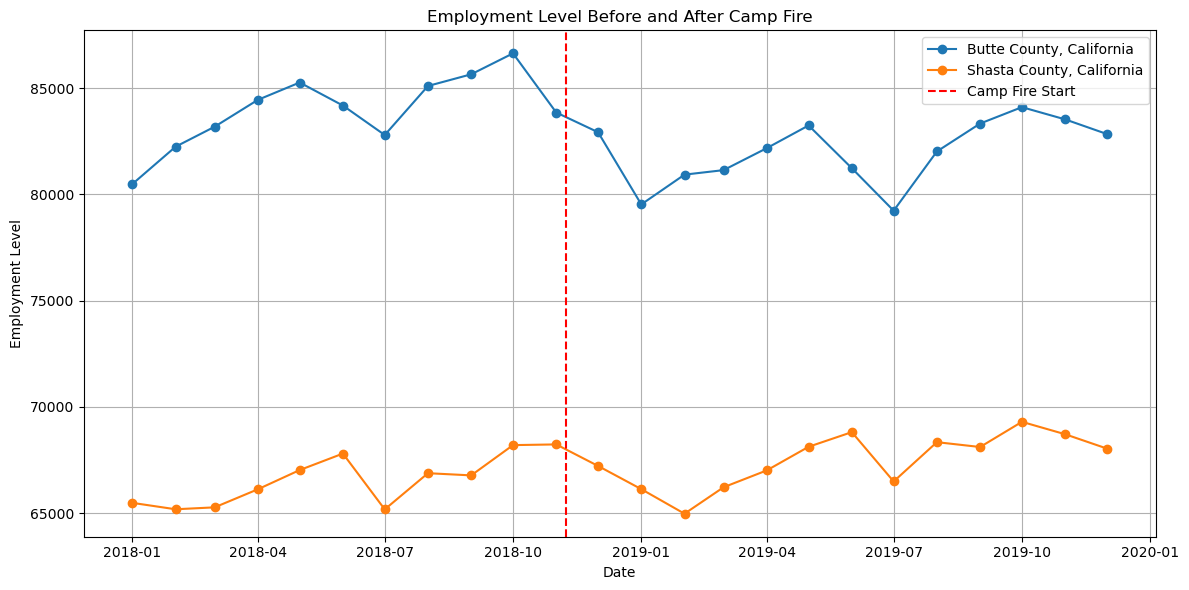

DID coefficient: -3009.67
P-value: 0.0009
Statistically significant wildfire effect detected.


In [86]:
plt.figure(figsize=(12, 6))

for area in target_areas:
    area_data = monthly_df[monthly_df["area_title"] == area]

    plt.plot(area_data["date"], area_data["employment_level"], marker="o", label=area)

plt.axvline(
    pd.Timestamp("2018-11-08"), color="red", linestyle="--", label="Camp Fire Start"
)

plt.title("Employment Level Before and After Camp Fire")
plt.xlabel("Date")
plt.ylabel("Employment Level")
plt.legend()
plt.grid(True)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../results/employment_level_butte_shasta_camp_fire.png")
plt.show()


did_coef = model.params["did"]
did_pvalue = model.pvalues["did"]

print(f"DID coefficient: {did_coef:.2f}")
print(f"P-value: {did_pvalue:.4f}")

if did_pvalue < 0.05:
    print("Statistically significant wildfire effect detected.")
else:
    print("No statistically significant wildfire effect detected.")

In [87]:
monthly_df

,date,area_title,employment_level,treated,post,did
0,2018-01-01,"Butte County, California",80491,1,0,0
1,2018-02-01,"Butte County, California",82248,1,0,0
2,2018-03-01,"Butte County, California",83189,1,0,0
3,2018-04-01,"Butte County, California",84454,1,0,0
4,2018-05-01,"Butte County, California",85270,1,0,0
5,2018-06-01,"Butte County, California",84185,1,0,0
6,2018-07-01,"Butte County, California",82799,1,0,0
7,2018-08-01,"Butte County, California",85107,1,0,0
8,2018-09-01,"Butte County, California",85657,1,0,0
9,2018-10-01,"Butte County, California",86643,1,0,0


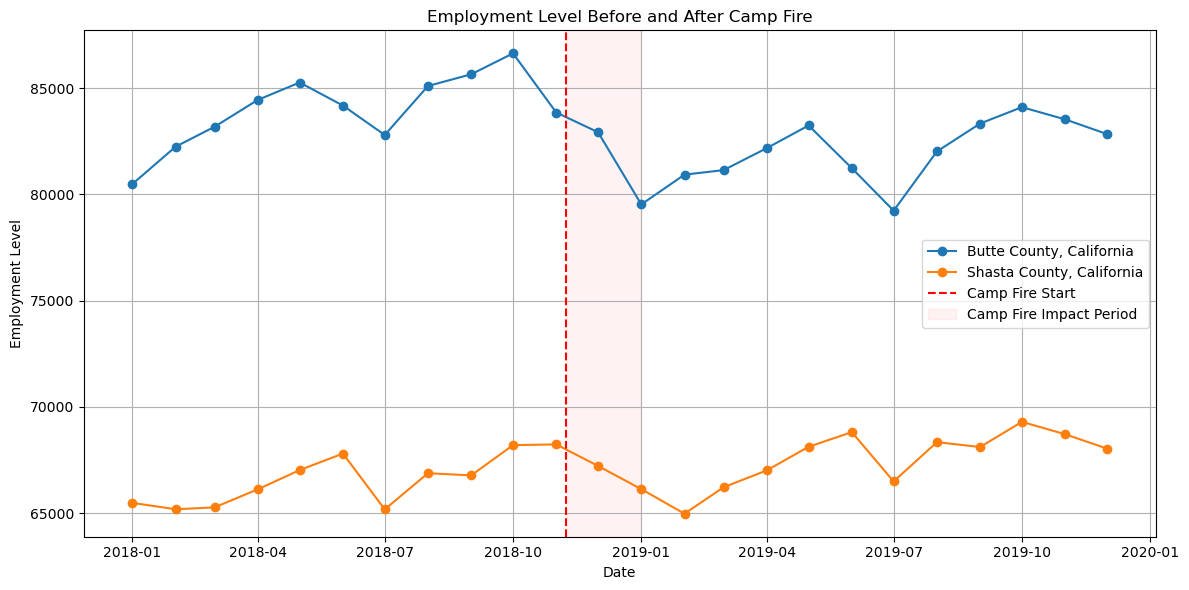

DID coefficient: -3009.67
P-value: 0.0009
Statistically significant wildfire effect detected.


In [88]:
plt.figure(figsize=(12, 6))

for area in target_areas:
    area_data = monthly_df[monthly_df["area_title"] == area]

    plt.plot(area_data["date"], area_data["employment_level"], marker="o", label=area)

plt.axvline(
    pd.Timestamp("2018-11-08"), color="red", linestyle="--", label="Camp Fire Start"
)

plt.axvspan(
    pd.Timestamp("2018-11-08"),
    pd.Timestamp("2019-01-01"),
    color="red",
    alpha=0.05,
    label="Camp Fire Impact Period",
)

plt.title("Employment Level Before and After Camp Fire")
plt.xlabel("Date")
plt.ylabel("Employment Level")
plt.legend()
plt.grid(True)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../results/employment_level_butte_shasta_camp_fire_range.png")
plt.show()


did_coef = model.params["did"]
did_pvalue = model.pvalues["did"]

print(f"DID coefficient: {did_coef:.2f}")
print(f"P-value: {did_pvalue:.4f}")

if did_pvalue < 0.05:
    print("Statistically significant wildfire effect detected.")
else:
    print("No statistically significant wildfire effect detected.")

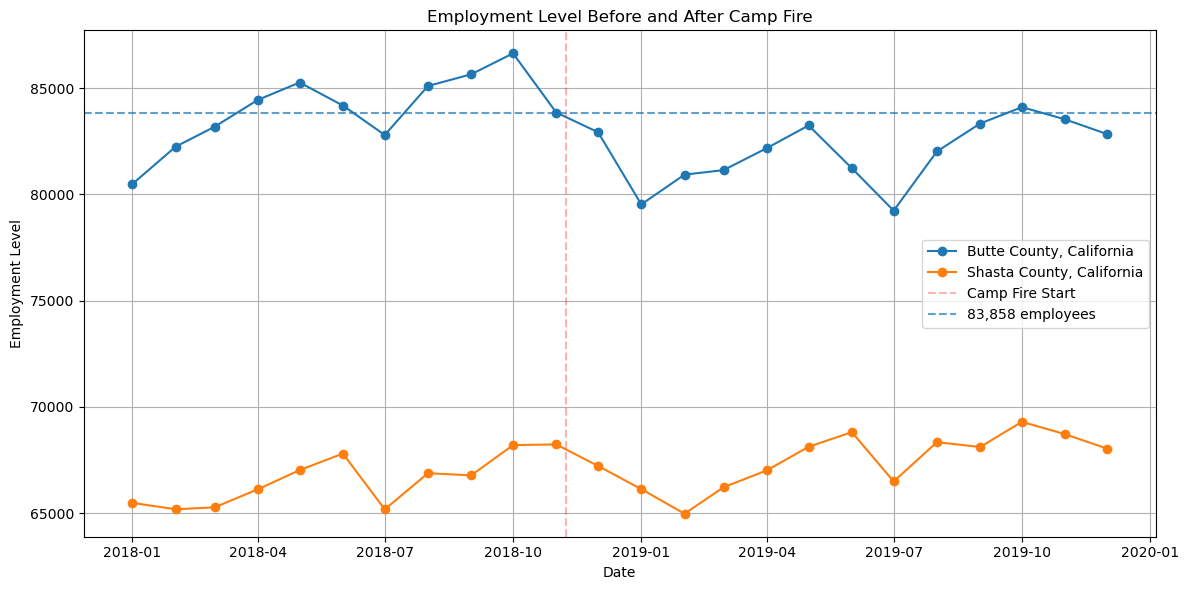

DID coefficient: -3009.67
P-value: 0.0009
Statistically significant wildfire effect detected.


In [89]:
plt.figure(figsize=(12, 6))

for area in target_areas:
    area_data = monthly_df[monthly_df["area_title"] == area]

    plt.plot(area_data["date"], area_data["employment_level"], marker="o", label=area)

plt.axvline(
    pd.Timestamp("2018-11-08"),
    color="red",
    linestyle="--",
    label="Camp Fire Start",
    alpha=0.3,
)

plt.axhline(y=83858, linestyle="--", alpha=0.7, label="83,858 employees")

plt.title("Employment Level Before and After Camp Fire")
plt.xlabel("Date")
plt.ylabel("Employment Level")
plt.legend()
plt.grid(True)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../results/employment_level_butte_shasta_camp_fire_range_come_back.png")
plt.show()


did_coef = model.params["did"]
did_pvalue = model.pvalues["did"]

print(f"DID coefficient: {did_coef:.2f}")
print(f"P-value: {did_pvalue:.4f}")

if did_pvalue < 0.05:
    print("Statistically significant wildfire effect detected.")
else:
    print("No statistically significant wildfire effect detected.")